<a href="https://colab.research.google.com/github/JoyJoyWang/ABTesting/blob/main/midterm2_zw673.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pygsp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.4 MB/s eta 0:00:00


# Q1

<Figure size 600x600 with 0 Axes>

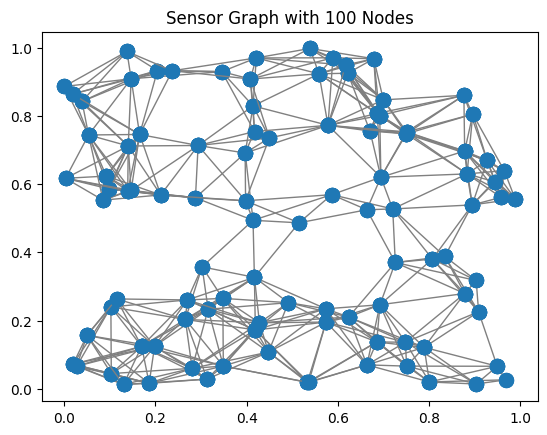

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pygsp import graphs, filters

# 1
G = graphs.Sensor(N=100, seed=1)

plt.figure(figsize=(6, 6))
G.plot()
plt.title("Sensor Graph with 100 Nodes")
plt.show()



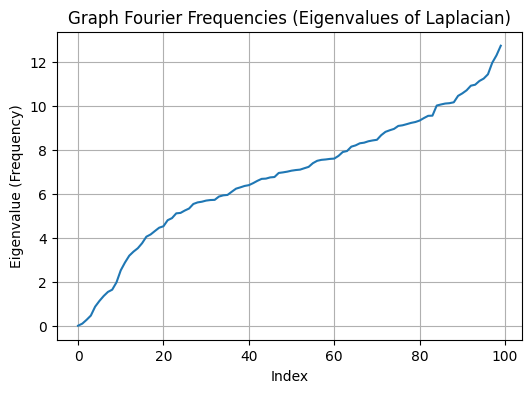

In [5]:
# 2. Compute its graph Fourier basis.
G.compute_fourier_basis()


plt.figure(figsize=(6, 4))
plt.plot(G.e)
plt.title("Graph Fourier Frequencies (Eigenvalues of Laplacian)")
plt.xlabel("Index")
plt.ylabel("Eigenvalue (Frequency)")
plt.grid(True)
plt.show()


In [6]:
import numpy as np

# 3. (1)

np.random.seed(1)
x = np.random.normal(loc=0.0, scale=1.0, size=G.N)
print("Sample of random graph signal x:", x[:10])

Sample of random graph signal x: [ 1.62434536 -0.61175641 -0.52817175 -1.07296862  0.86540763 -2.3015387
  1.74481176 -0.7612069   0.3190391  -0.24937038]


<Figure size 600x400 with 0 Axes>

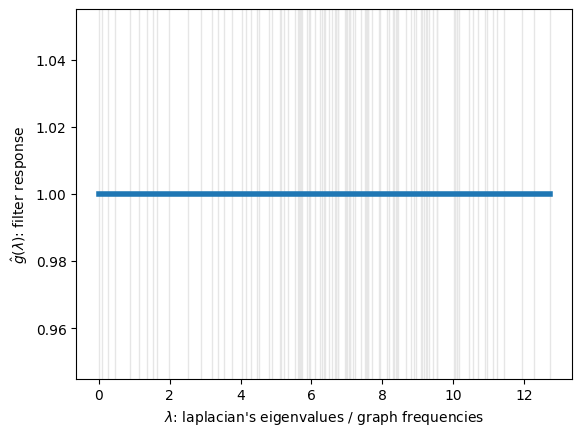

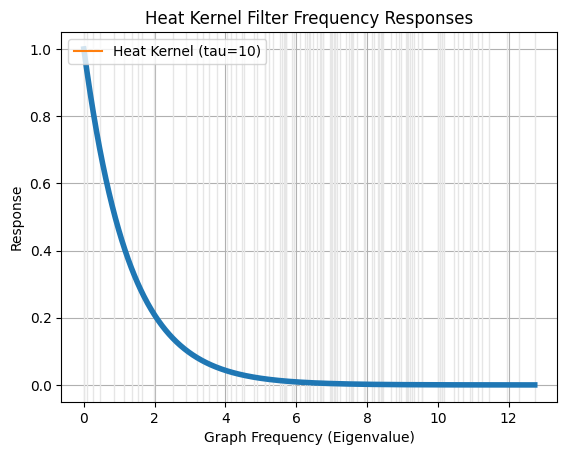

In [8]:
# 3. (2)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

from pygsp import filters

heat_lowpass = filters.Heat(G, tau=0)
heat_highpass = filters.Heat(G, tau=10)

heat_lowpass.plot()
plt.plot([], [], label='Heat Kernel (tau=0)')

heat_highpass.plot()
plt.plot([], [], label='Heat Kernel (tau=10)')

plt.title("Heat Kernel Filter Frequency Responses")
plt.xlabel("Graph Frequency (Eigenvalue)")
plt.ylabel("Response")
plt.legend()
plt.grid(True)
plt.show()



In [10]:
# 3. (3)
x_lowpass = heat_lowpass.filter(x)

x_highpass = heat_highpass.filter(x)


print("Original Signal (first 10 values):\n", x[:10])
print("Low-pass Filtered Signal (tau=0):\n", x_lowpass[:10])
print("High-pass Filtered Signal (tau=10):\n", x_highpass[:10])

Original Signal (first 10 values):
 [ 1.62434536 -0.61175641 -0.52817175 -1.07296862  0.86540763 -2.3015387
  1.74481176 -0.7612069   0.3190391  -0.24937038]
Low-pass Filtered Signal (tau=0):
 [ 1.62434536 -0.61175641 -0.52817175 -1.07296862  0.86540763 -2.3015387
  1.74481176 -0.7612069   0.3190391  -0.24937038]
High-pass Filtered Signal (tau=10):
 [ 0.207148    0.05791657 -0.14676201  0.18714158 -0.14819161 -0.20406852
  0.32897266 -0.09871139  0.04048785 -0.0456028 ]


In [11]:
# 4.

x_hat_lowpass = G.U.T @ x_lowpass
x_hat_highpass = G.U.T @ x_highpass

print("Low-pass Graph Fourier Transform (first 10):\n", np.round(x_hat_lowpass[:10], 3))
print("High-pass Graph Fourier Transform (first 10):\n", np.round(x_hat_highpass[:10], 3))


Low-pass Graph Fourier Transform (first 10):
 [ 0.606 -1.379 -0.277 -0.838  0.17  -0.257  0.257  0.549  1.293  0.16 ]
High-pass Graph Fourier Transform (first 10):
 [ 0.606 -1.279 -0.224 -0.583  0.086 -0.106  0.089  0.164  0.357  0.034]


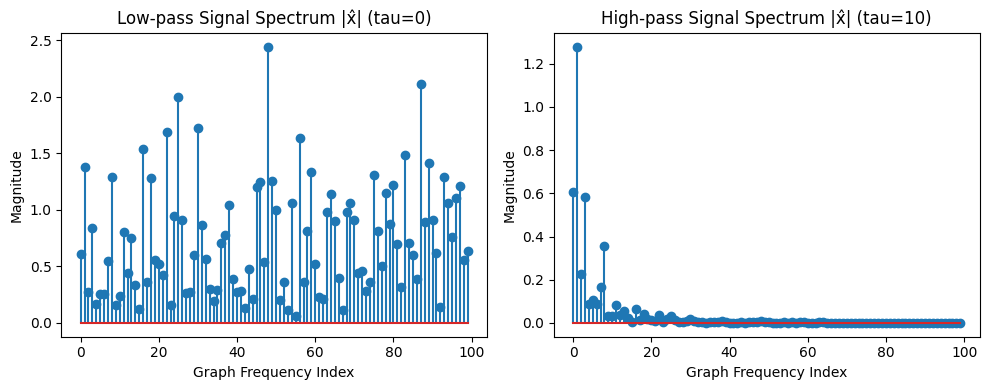

In [13]:
# 5.

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.stem(np.abs(x_hat_lowpass))
plt.title("Low-pass Signal Spectrum |x̂| (tau=0)")
plt.xlabel("Graph Frequency Index")
plt.ylabel("Magnitude")

plt.subplot(1, 2, 2)
plt.stem(np.abs(x_hat_highpass))
plt.title("High-pass Signal Spectrum |x̂| (tau=10)")
plt.xlabel("Graph Frequency Index")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()


In [14]:
# 6.

L = G.L

smooth_low = x_lowpass.T @ L @ x_lowpass
smooth_high = x_highpass.T @ L @ x_highpass

print(f"Smoothness of low-pass signal: {smooth_low:.4f}")
print(f"Smoothness of high-pass signal: {smooth_high:.4f}")


Smoothness of low-pass signal: 567.9986
Smoothness of high-pass signal: 0.6968


In [ ]:
# 7.
# The graph signal generated by scale = 10 is a low-pass graph signal.

# Q2

In [ ]:
!pip install torch_geometric

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pygsp import graphs
from torch_geometric.datasets import Planetoid
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

Text(0.5, 1.0, 'Erdős-Rényi Graph')

<Figure size 640x480 with 0 Axes>

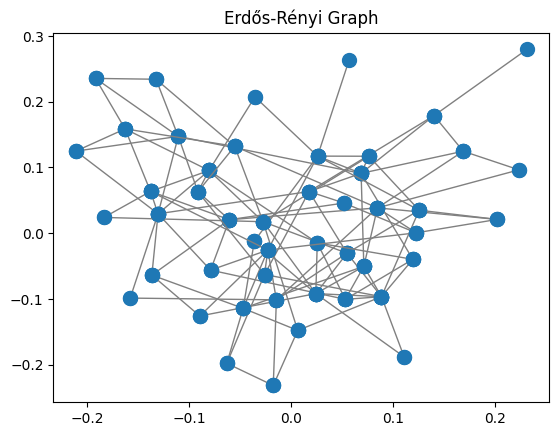

In [21]:
# 1. (a)


G_er = graphs.ErdosRenyi(N=50, p=0.1)

plt.figure()
G_er.set_coordinates()
G_er.plot()
plt.title("Erdős-Rényi Graph")

Text(0.5, 1.0, 'Ring Graph')

<Figure size 640x480 with 0 Axes>

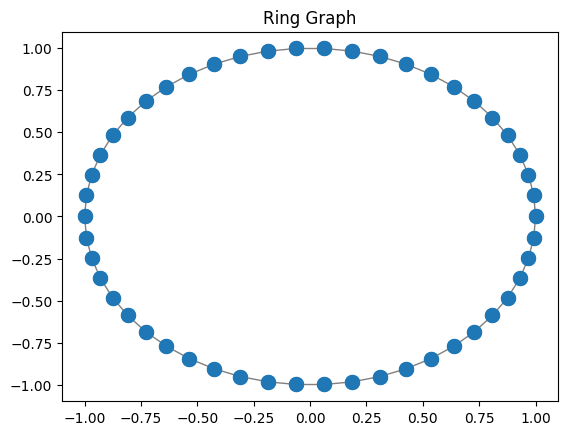

In [22]:
# 1. (b)

G_ring = graphs.Ring(N=50)
plt.figure()
G_ring.plot()
plt.title("Ring Graph")


In [23]:
# 1. (c)

cora = Planetoid(root='/tmp/Cora', name='Cora')[0]
edge_index = cora.edge_index
num_nodes = cora.num_nodes
adj = torch.zeros((num_nodes, num_nodes))
adj[edge_index[0], edge_index[1]] = 1
adj = (adj + adj.T) / 2


W = adj.numpy()
G_cora = graphs.Graph(W)
G_cora.compute_laplacian()


Processing...
Done!


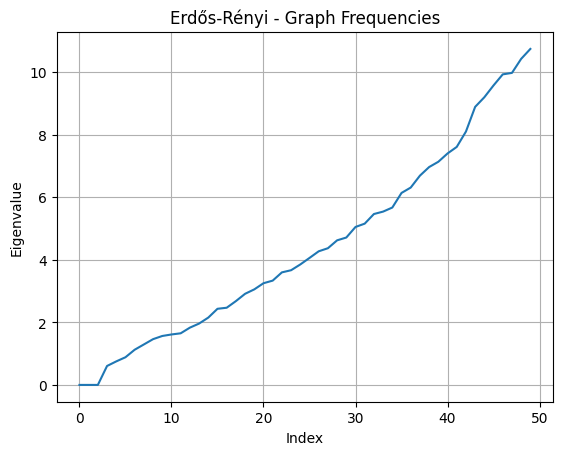

In [25]:
# 2.
def plot_graph_frequencies(G, title):
    G.compute_fourier_basis()
    plt.plot(np.sort(G.e))
    plt.title(f"{title} - Graph Frequencies")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.grid(True)
    plt.show()

plot_graph_frequencies(G_er, "Erdős-Rényi")



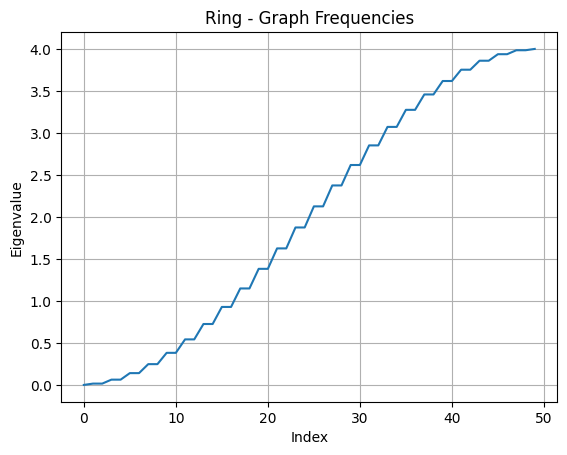

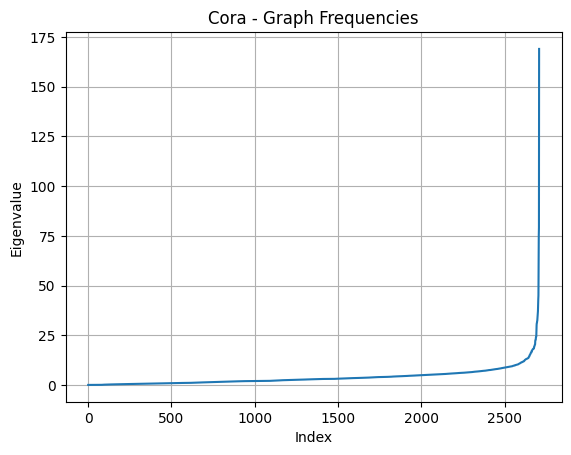

In [26]:
plot_graph_frequencies(G_ring, "Ring")
plot_graph_frequencies(G_cora, "Cora")


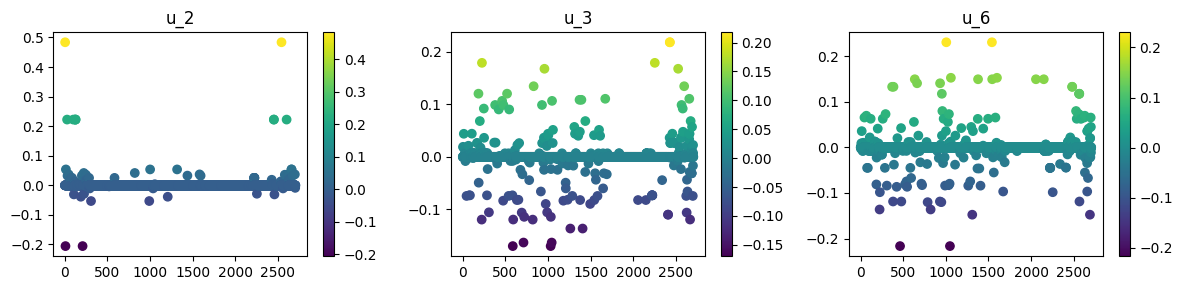

In [27]:

G_cora.compute_fourier_basis()
U = G_cora.U
plt.figure(figsize=(12, 3))
for i, k in enumerate([1, 2, 5]):
    plt.subplot(1, 3, i+1)
    plt.scatter(np.arange(G_cora.N), U[:, k], c=U[:, k], cmap='viridis')
    plt.title(f"u_{k+1}")
    plt.colorbar()
plt.tight_layout()
plt.show()

Adjusted Rand Index: 0.1143
Silhouette Score: 0.3562


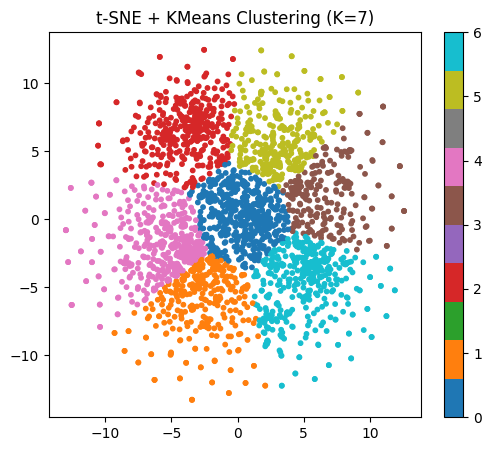

In [28]:
# 3.
X = cora.x.numpy()
y_true = cora.y.numpy()

X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X)


kmeans = KMeans(n_clusters=7, random_state=0).fit(X_tsne)
y_pred = kmeans.labels_

ari = adjusted_rand_score(y_true, y_pred)
sil = silhouette_score(X_tsne, y_pred)

print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {sil:.4f}")

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred, cmap='tab10', s=10)
plt.title("t-SNE + KMeans Clustering (K=7)")
plt.colorbar()
plt.show()


In [30]:
# 4. a

import numpy as np
import matplotlib.pyplot as plt
from pygsp import graphs, filters

N = 100
G = graphs.Ring(N)
G.compute_fourier_basis()

# x = sin(i) + cos(2i) + 0.5*cos(30i)
i = np.linspace(-np.pi, np.pi, N)
x_clean = np.sin(i) + np.cos(2*i) + 0.5 * np.cos(30*i)


noise = np.random.uniform(-0.4, 0.4, N)
x_noisy = x_clean + noise



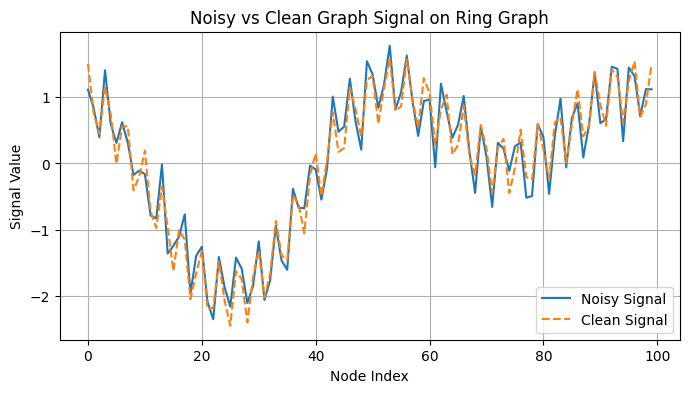

In [31]:
# b.

plt.figure(figsize=(8, 4))
plt.plot(x_noisy, label="Noisy Signal")
plt.plot(x_clean, label="Clean Signal", linestyle="--")
plt.legend()
plt.title("Noisy vs Clean Graph Signal on Ring Graph")
plt.xlabel("Node Index")
plt.ylabel("Signal Value")
plt.grid(True)
plt.show()


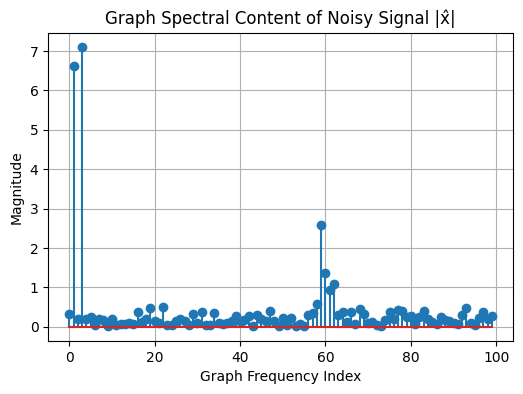

In [32]:
# c.

x_hat_noisy = G.U.T @ x_noisy

plt.figure(figsize=(6, 4))
plt.stem(np.abs(x_hat_noisy))
plt.title("Graph Spectral Content of Noisy Signal |x̂|")
plt.xlabel("Graph Frequency Index")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


In [33]:
# d.
alpha = 2
h = lambda x: 1 / (1 + alpha * x)
g = filters.Filter(G, h)


In [34]:
# e.
x_denoised = g.filter(x_noisy, method='exact')


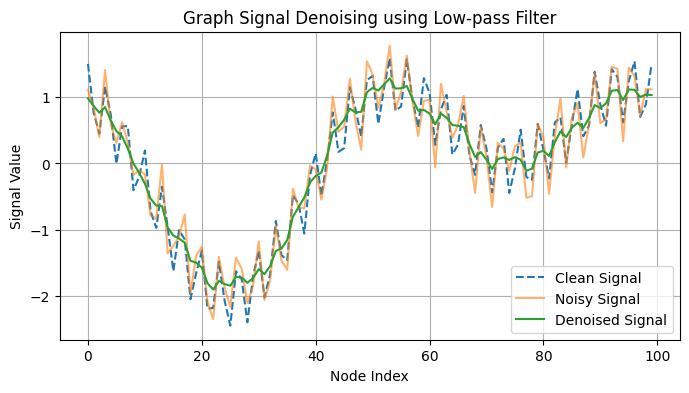

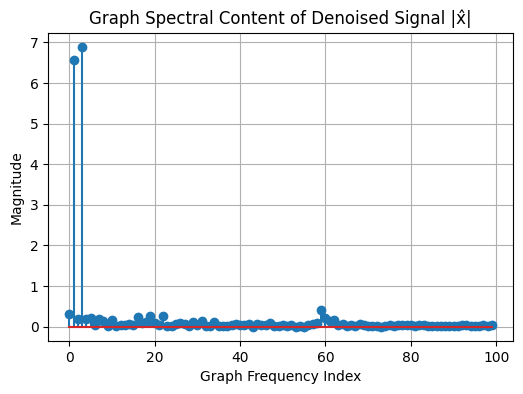

In [35]:
# f.
plt.figure(figsize=(8, 4))
plt.plot(x_clean, label="Clean Signal", linestyle="--")
plt.plot(x_noisy, label="Noisy Signal", alpha=0.6)
plt.plot(x_denoised, label="Denoised Signal")
plt.legend()
plt.title("Graph Signal Denoising using Low-pass Filter")
plt.xlabel("Node Index")
plt.ylabel("Signal Value")
plt.grid(True)
plt.show()


x_hat_denoised = G.U.T @ x_denoised
plt.figure(figsize=(6, 4))
plt.stem(np.abs(x_hat_denoised))
plt.title("Graph Spectral Content of Denoised Signal |x̂|")
plt.xlabel("Graph Frequency Index")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


# 3.

In [36]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import ChebConv
from torch_geometric.datasets import Planetoid


dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]


class ChebNet(torch.nn.Module):
    def __init__(self):
        super(ChebNet, self).__init__()
        self.conv1 = ChebConv(dataset.num_node_features, 40, K=5)  # 第一层
        self.conv2 = ChebConv(40, dataset.num_classes, K=5)        # 第二层

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


In [37]:
model = ChebNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
loss_fn = F.nll_loss  # negative log likelihood loss

losses = []
for epoch in range(201):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}")


Epoch 000, Loss: 2.0034
Epoch 020, Loss: 0.0000
Epoch 040, Loss: 0.0001
Epoch 060, Loss: 0.0003
Epoch 080, Loss: 0.0016
Epoch 100, Loss: 0.0018
Epoch 120, Loss: 0.0019
Epoch 140, Loss: 0.0019
Epoch 160, Loss: 0.0019
Epoch 180, Loss: 0.0019
Epoch 200, Loss: 0.0018


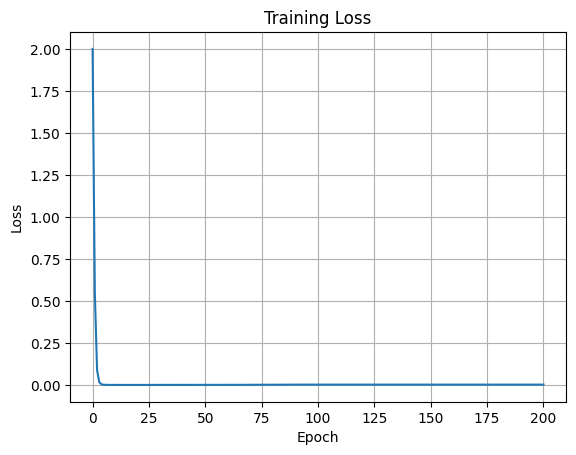

In [38]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [39]:
model.eval()
out = model(data)
pred = out.argmax(dim=1)


correct = pred[data.test_mask] == data.y[data.test_mask]
acc = int(correct.sum()) / int(data.test_mask.sum())
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.7660


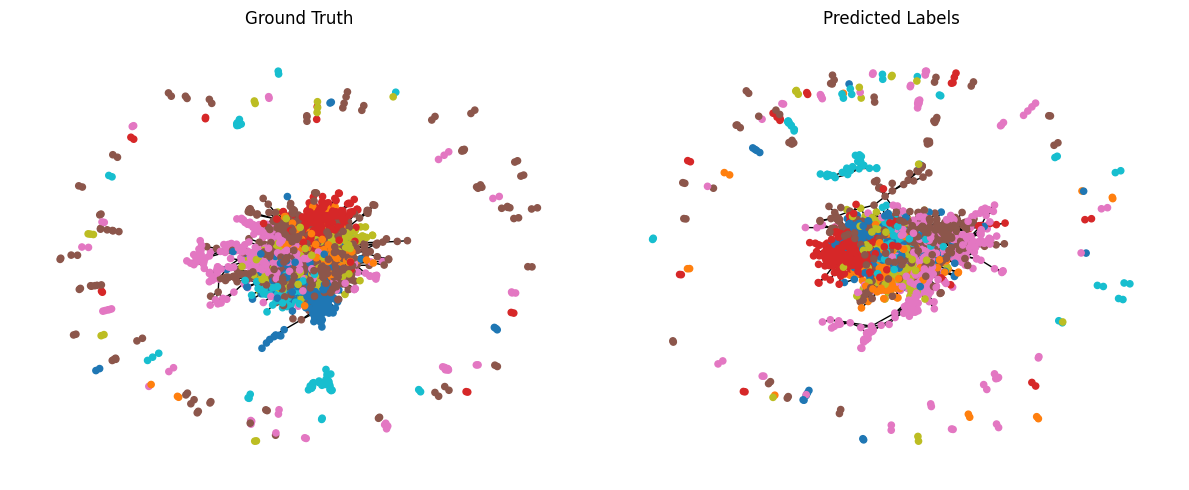

In [41]:
import networkx as nx
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
nx.draw(G, node_color=data.y, node_size=20, cmap="tab10")
plt.title("Ground Truth")

plt.subplot(1, 2, 2)
nx.draw(G, node_color=pred, node_size=20, cmap="tab10")
plt.title("Predicted Labels")

plt.tight_layout()
plt.show()
